### 1. DESCRIPTION

**Air Passengers Prediction**

**Dataset** : Air Passengers (1949–1960)

**Source** : https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

**Total rows** : 144

**Total features** : 2 

**Target** : Passengers

---

**Objective** :  
To build a model that predicts monthly air passenger numbers using historical data.  
The main goal is to understand trends and seasonal patterns in passenger counts and generate a 12-month ahead forecast using **SARIMA** and **Prophet (Facebook)**.

---

**Workflow** :

1. Description  
2. Import Libraries  
3. Load Data  
4. Data Understanding  
5. Exploratory Data Analysis (EDA)  
6. Train-Test Split  
7. Modelling
8. Future Forecast  
9. Save Models & Data for Streamlit Deployment
10. Summary & Insight

### 2. IMPORT LIBRARIES

In [82]:
# Install required packages (uncomment jika belum terinstall)
%pip install pandas numpy matplotlib seaborn statsmodels prophet scikit-learn plotly --break-system-packages

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.graph_objects as go
import plotly.express as px
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### 3. LOAD DATASET

In [84]:
# Load dataset Air Passengers (dataset publik klasik)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url)

In [85]:
# Rename columns
df.columns = ['Month', 'Passengers']

In [86]:
# Convert to datetime
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month')

In [87]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (144, 1)


In [88]:
print(f"\nDate range: {df.index.min()} to {df.index.max()}")


Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


In [89]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### 4. DATA UNDERSTANDING

In [90]:
print(df.describe())

       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


In [91]:
df.isnull().sum()

Passengers    0
dtype: int64

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


### 5. EXPLORATORY DATA ANALYSIS (EDA)

**Plot 1: Original Time Series**

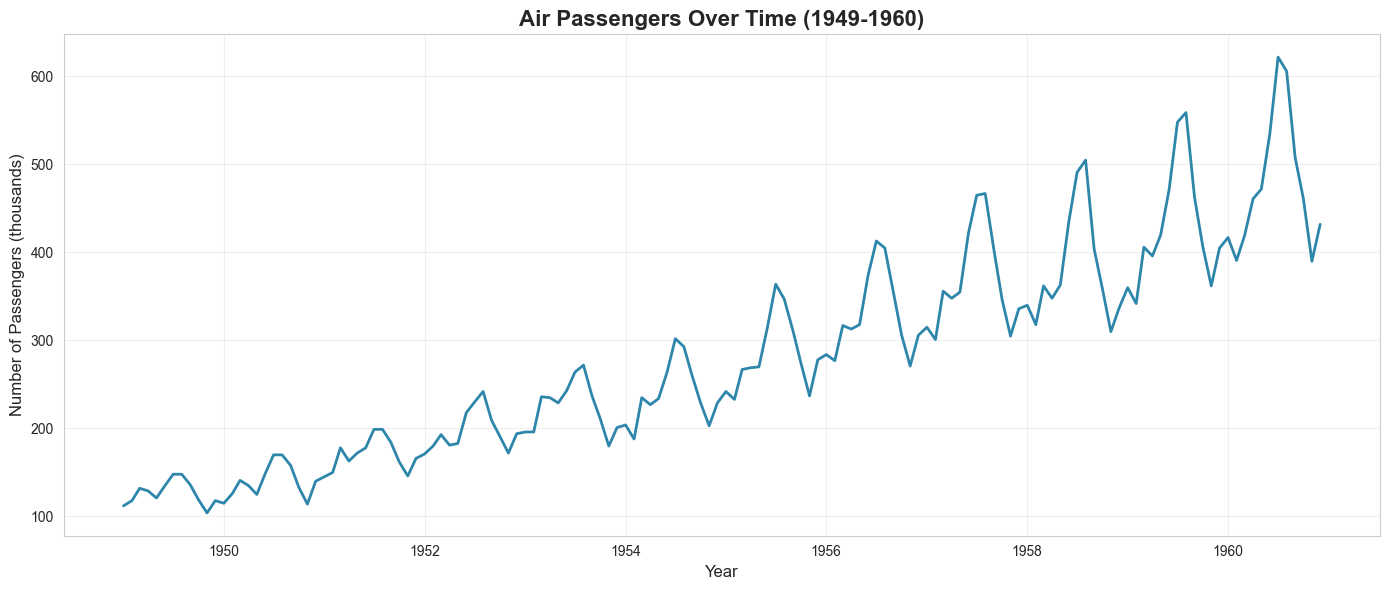

Observation: Clear upward trend and seasonal pattern visible


In [93]:
# Plot original time series
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Passengers'], linewidth=2, color='#2E86AB')
ax.set_title('Air Passengers Over Time (1949-1960)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Passengers (thousands)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation: Clear upward trend and seasonal pattern visible")

**Plot 2: Seasonal Decomposition**

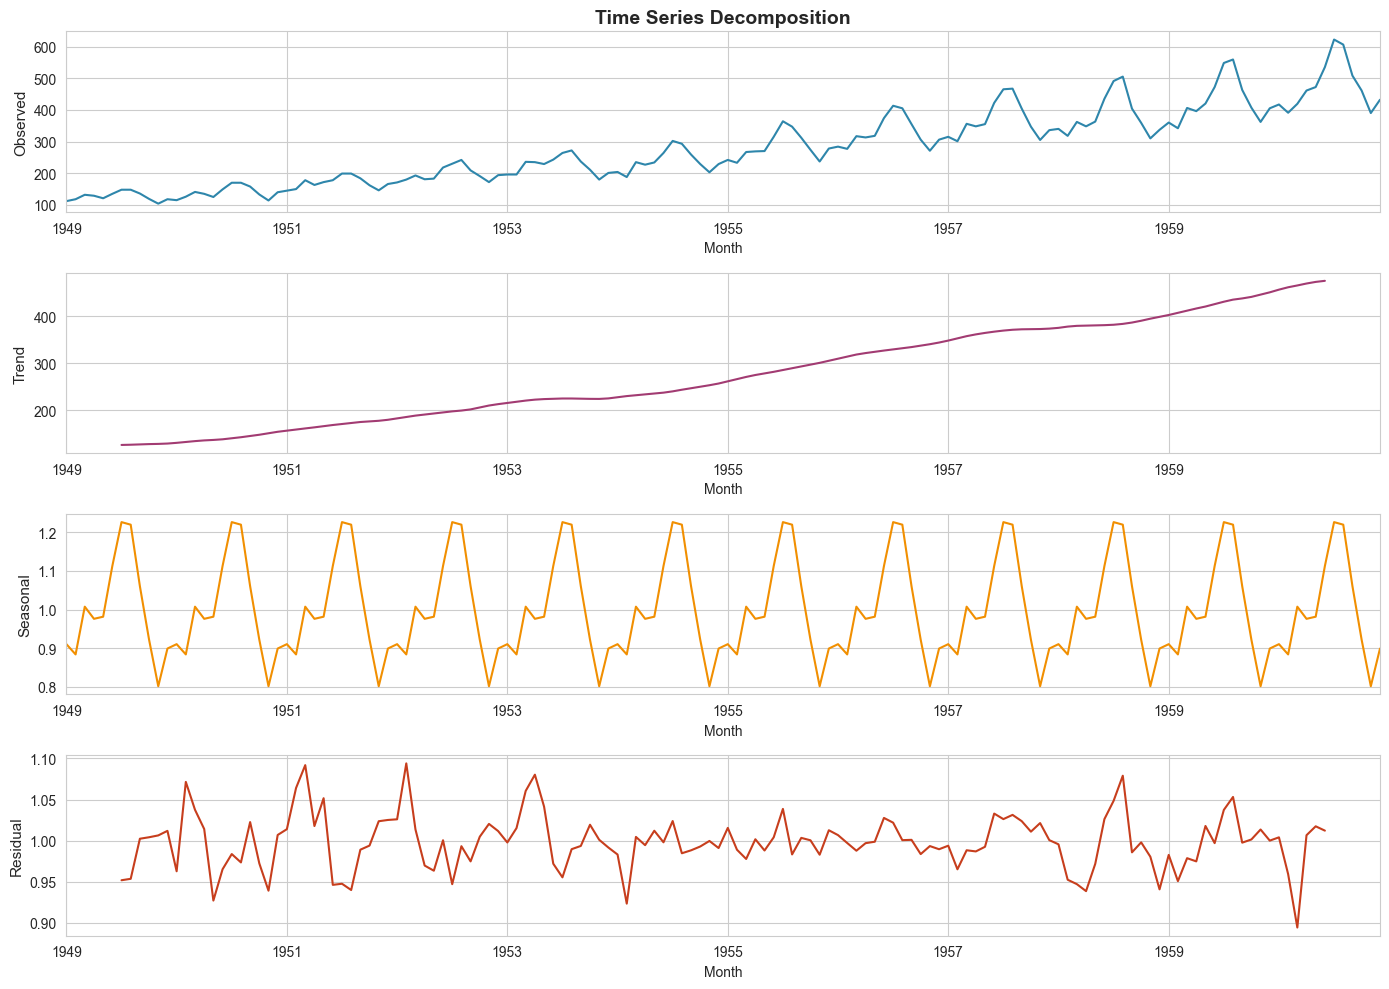

In [94]:
# Seasonal Decomposition
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=axes[0], color='#2E86AB')
axes[0].set_ylabel('Observed', fontsize=11)
axes[0].set_title('Time Series Decomposition', fontsize=14, fontweight='bold')

decomposition.trend.plot(ax=axes[1], color='#A23B72')
axes[1].set_ylabel('Trend', fontsize=11)

decomposition.seasonal.plot(ax=axes[2], color='#F18F01')
axes[2].set_ylabel('Seasonal', fontsize=11)

decomposition.resid.plot(ax=axes[3], color='#C73E1D')
axes[3].set_ylabel('Residual', fontsize=11)

plt.tight_layout()
plt.show()

In [95]:
# Stationarity Test (Augmented Dickey-Fuller Test)
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(f'ADF Test: {title}')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print("✅ Data is STATIONARY (reject H0)\n")
    else:
        print("❌ Data is NON-STATIONARY (fail to reject H0)\n")

adf_test(df['Passengers'], 'Original Series')

ADF Test: Original Series
ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579
❌ Data is NON-STATIONARY (fail to reject H0)



**Plot 3: ACF and PACF**

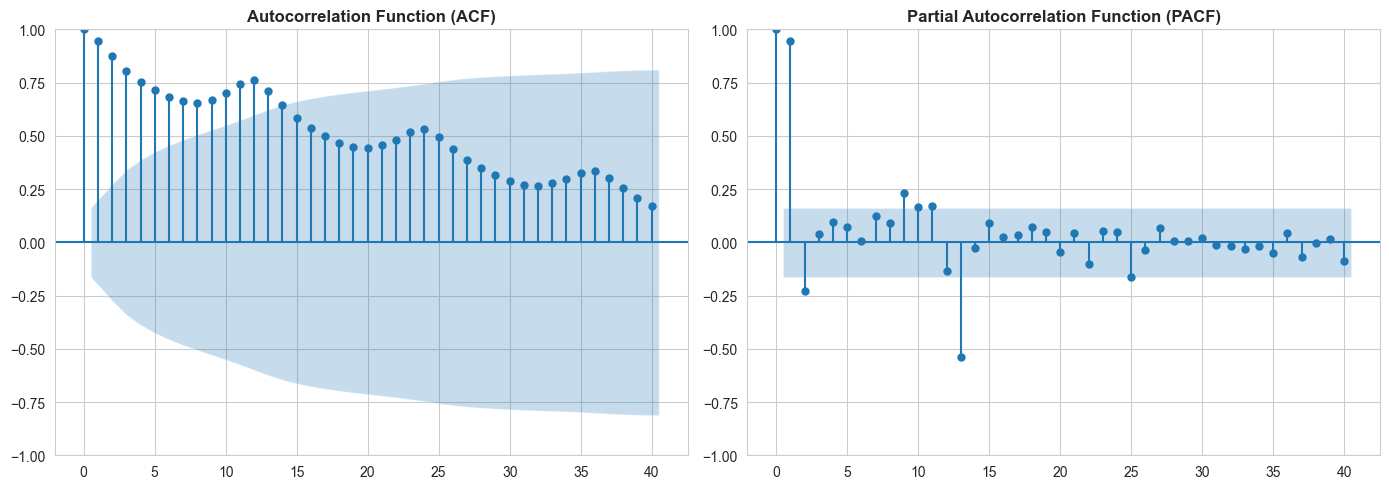

In [96]:
# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df['Passengers'], lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')

plot_pacf(df['Passengers'], lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 6. TRAIN-TEST SPLIT

In [97]:
# Split data: 80% train, 20% test
train_size = int(len(df) * 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

print(f"Training set: {train_data.index.min()} to {train_data.index.max()} ({len(train_data)} observations)")
print(f"Test set: {test_data.index.min()} to {test_data.index.max()} ({len(test_data)} observations)")

Training set: 1949-01-01 00:00:00 to 1958-07-01 00:00:00 (115 observations)
Test set: 1958-08-01 00:00:00 to 1960-12-01 00:00:00 (29 observations)


**Plot 4: Train-Test Split**

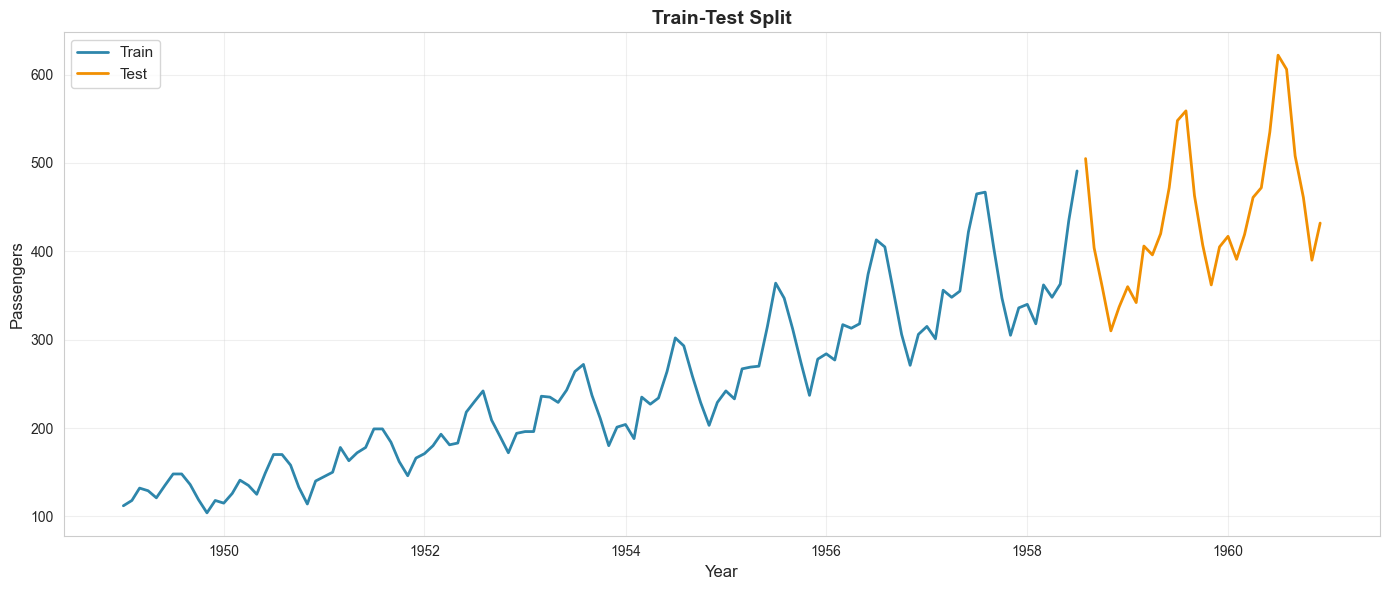

In [98]:
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data['Passengers'], label='Train', color='#2E86AB', linewidth=2)
plt.plot(test_data.index, test_data['Passengers'], label='Test', color='#F18F01', linewidth=2)
plt.title('Train-Test Split', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Passengers', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7. MODEL

**Model 1: SARIMA (Seasonal ARIMA)**

In [99]:
# SARIMA Model
# Parameters: (p,d,q) x (P,D,Q,s)
# s=12 untuk seasonal period (monthly data)

print("🔄 Training SARIMA model...")

sarima_model = SARIMAX(train_data['Passengers'], 
                       order=(1, 1, 1),  # (p, d, q)
                       seasonal_order=(1, 1, 1, 12),  # (P, D, Q, s)
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_result = sarima_model.fit(disp=False)

print("✅ SARIMA model trained!")
print("\n📋 Model Summary:")
print(sarima_result.summary())

🔄 Training SARIMA model...
✅ SARIMA model trained!

📋 Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  115
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -323.801
Date:                            Sun, 08 Mar 2026   AIC                            657.601
Time:                                    10:24:09   BIC                            669.988
Sample:                                01-01-1949   HQIC                           662.592
                                     - 07-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8224      0.184     -4.461  

In [100]:
# Make predictions on test set
sarima_predictions = sarima_result.forecast(steps=len(test_data))

**Plot 5: SARIMA Forecast vs Actual**

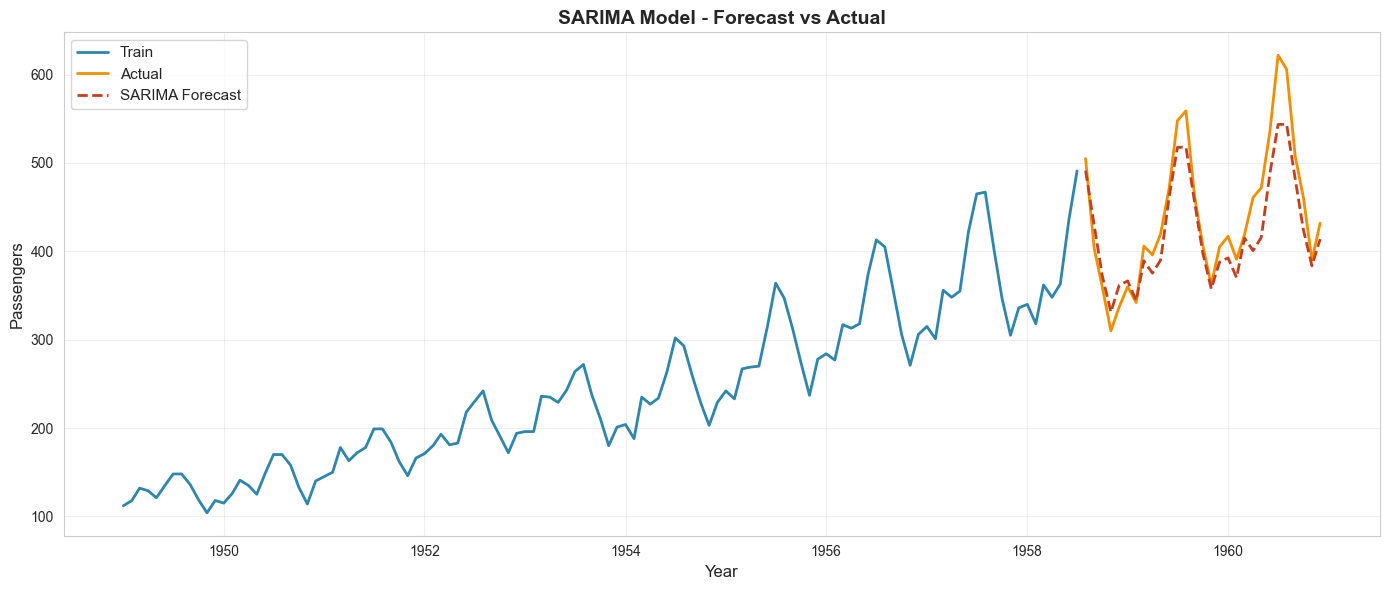

In [101]:
# Plot predictions
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data['Passengers'], label='Train', color='#2E86AB', linewidth=2)
plt.plot(test_data.index, test_data['Passengers'], label='Actual', color='#F18F01', linewidth=2)
plt.plot(test_data.index, sarima_predictions, label='SARIMA Forecast', color='#C73E1D', linewidth=2, linestyle='--')
plt.title('SARIMA Model - Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Passengers', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [102]:
# SARIMA Evaluation Metrics
sarima_mae = mean_absolute_error(test_data['Passengers'], sarima_predictions)
sarima_rmse = np.sqrt(mean_squared_error(test_data['Passengers'], sarima_predictions))
sarima_mape = np.mean(np.abs((test_data['Passengers'] - sarima_predictions) / test_data['Passengers'])) * 100
sarima_r2 = r2_score(test_data['Passengers'], sarima_predictions)

In [103]:
print("📊 SARIMA Model Evaluation:")
print(f"MAE (Mean Absolute Error): {sarima_mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {sarima_rmse:.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {sarima_mape:.2f}%")
print(f"R² Score: {sarima_r2:.4f}")

📊 SARIMA Model Evaluation:
MAE (Mean Absolute Error): 25.27
RMSE (Root Mean Squared Error): 31.79
MAPE (Mean Absolute Percentage Error): 5.43%
R² Score: 0.8345


**Model 2: Prophet (Facebook)**

In [104]:
# Prepare data for Prophet (requires 'ds' and 'y' columns)
train_prophet = train_data.reset_index()
train_prophet.columns = ['ds', 'y']

test_prophet = test_data.reset_index()
test_prophet.columns = ['ds', 'y']

In [105]:
print("🔄 Training Prophet model...")

# Initialize and fit Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

prophet_model.fit(train_prophet)

print("✅ Prophet model trained!")

10:24:10 - cmdstanpy - INFO - Chain [1] start processing


🔄 Training Prophet model...


10:24:10 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained!


In [106]:
# Make predictions
future = prophet_model.make_future_dataframe(periods=len(test_data), freq='MS')
prophet_forecast = prophet_model.predict(future)

# Extract predictions for test period
prophet_predictions = prophet_forecast.iloc[-len(test_data):]['yhat'].values

**Plot 6: Prophet Forecast**

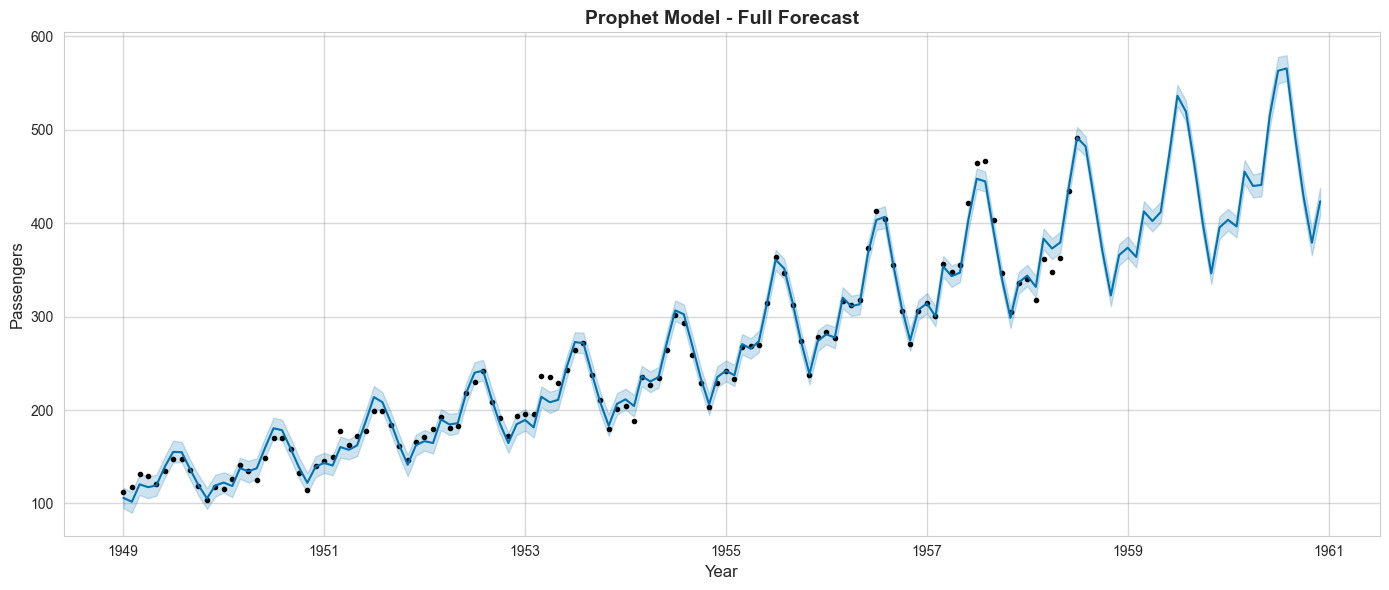

In [107]:
# Plot Prophet forecast
fig = prophet_model.plot(prophet_forecast, figsize=(14, 6))
plt.title('Prophet Model - Full Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Passengers', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Plot 7: Prophet Components**

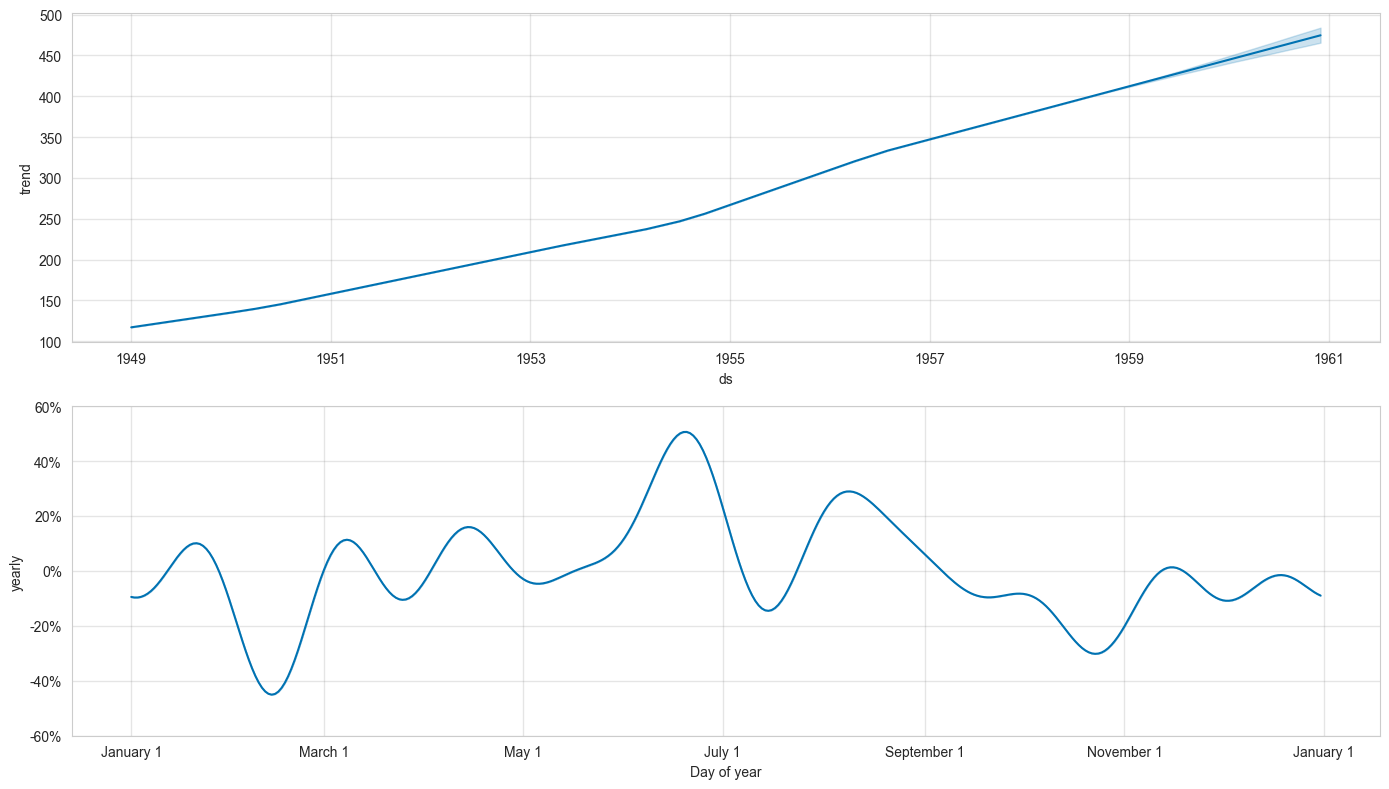

In [108]:
# Plot components
fig = prophet_model.plot_components(prophet_forecast, figsize=(14, 8))
plt.tight_layout()
plt.show()

In [109]:
# Prophet Evaluation Metrics
prophet_mae = mean_absolute_error(test_data['Passengers'], prophet_predictions)
prophet_rmse = np.sqrt(mean_squared_error(test_data['Passengers'], prophet_predictions))
prophet_mape = np.mean(np.abs((test_data['Passengers'] - prophet_predictions) / test_data['Passengers'])) * 100
prophet_r2 = r2_score(test_data['Passengers'], prophet_predictions)

In [110]:
print("📊 Prophet Model Evaluation:")
print(f"MAE (Mean Absolute Error): {prophet_mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {prophet_rmse:.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {prophet_mape:.2f}%")
print(f"R² Score: {prophet_r2:.4f}")

📊 Prophet Model Evaluation:
MAE (Mean Absolute Error): 18.32
RMSE (Root Mean Squared Error): 22.59
MAPE (Mean Absolute Percentage Error): 4.06%
R² Score: 0.9164


**Model Comparison**

In [111]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet'],
    'MAE': [sarima_mae, prophet_mae],
    'RMSE': [sarima_rmse, prophet_rmse],
    'MAPE (%)': [sarima_mape, prophet_mape],
    'R² Score': [sarima_r2, prophet_r2]
})

In [112]:
print("\n📊 Model Comparison:")
print(comparison_df.to_string(index=False))

# Determine best model
best_model = comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']
print(f"\n🏆 Best Model (lowest RMSE): {best_model}")


📊 Model Comparison:
  Model       MAE      RMSE  MAPE (%)  R² Score
 SARIMA 25.268046 31.787298  5.427511  0.834477
Prophet 18.319221 22.589050  4.064201  0.916411

🏆 Best Model (lowest RMSE): Prophet


**Plot 8: Model Comparison - Forecast vs Actual**

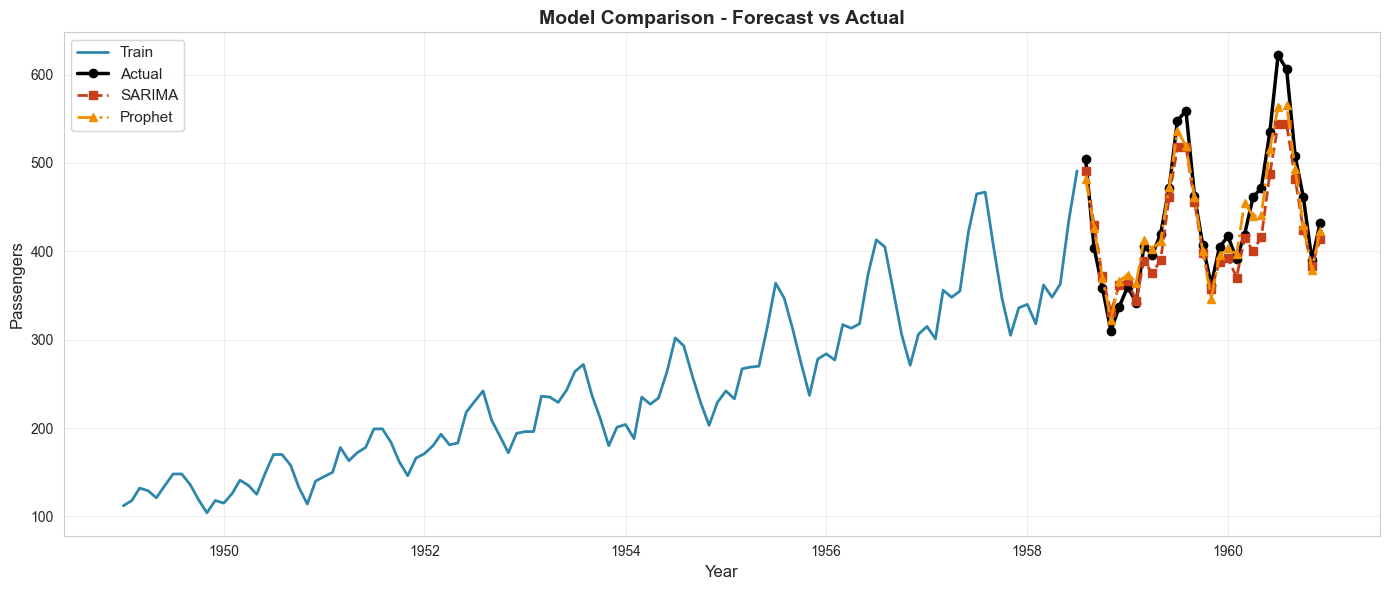

In [113]:
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data['Passengers'], label='Train', color='#2E86AB', linewidth=2)
plt.plot(test_data.index, test_data['Passengers'], label='Actual', color='black', linewidth=2.5, marker='o')
plt.plot(test_data.index, sarima_predictions, label='SARIMA', color='#C73E1D', linewidth=2, linestyle='--', marker='s')
plt.plot(test_data.index, prophet_predictions, label='Prophet', color='#F18F01', linewidth=2, linestyle='-.', marker='^')
plt.title('Model Comparison - Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Passengers', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8. FUTURE FORCASTING (12 MONTHS AHEAD)

In [114]:
# Retrain on full dataset for future predictions
print("🔄 Retraining models on full dataset...")

🔄 Retraining models on full dataset...


In [115]:
# SARIMA on full dataset
sarima_full = SARIMAX(
    df['Passengers'], 
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_full_result = sarima_full.fit(disp=False)
sarima_future = sarima_full_result.forecast(steps=12)

print("✅ SARIMA retrained and 12-month forecast generated.")

✅ SARIMA retrained and 12-month forecast generated.


In [116]:
# Prophet on full dataset
full_prophet = df.reset_index()
full_prophet.columns = ['ds', 'y']

prophet_full = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

prophet_full.fit(full_prophet)

# Forecast next 12 months
future_dates = prophet_full.make_future_dataframe(periods=12, freq='MS')
prophet_future_forecast = prophet_full.predict(future_dates)
prophet_future = prophet_future_forecast.iloc[-12:]['yhat'].values

print("✅ Prophet retrained and 12-month forecast generated.")

10:24:13 - cmdstanpy - INFO - Chain [1] start processing
10:24:13 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet retrained and 12-month forecast generated.


In [117]:
# 4️⃣ Summary of retrained models
print("✅ Both models retrained successfully!")
print(f"SARIMA 12-month forecast:\n{sarima_future.values}")
print(f"\nProphet 12-month forecast:\n{prophet_future}")

✅ Both models retrained successfully!
SARIMA 12-month forecast:
[447.22262032 422.73409889 457.70089523 492.27750558 505.56336622
 565.67178245 651.98640458 639.6342429  543.05884561 493.727026
 426.93800148 470.13560911]

Prophet 12-month forecast:
[449.7282301  431.00623568 491.48195048 492.95125805 502.17459797
 577.08606634 651.4315856  648.13250424 551.3954446  487.22661989
 422.96394038 471.90439331]


In [118]:
# Create future dates
last_date = df.index[-1]
future_dates_range = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

**Plot 9: 12-Month Future Forecast**

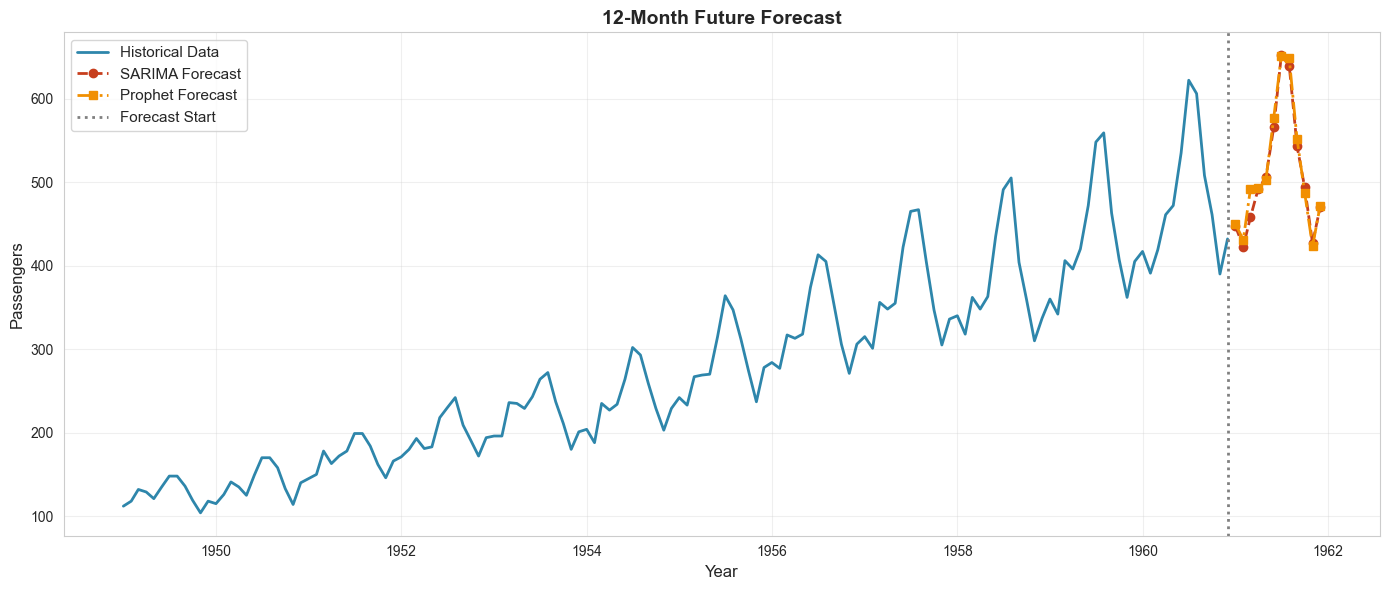

In [119]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Passengers'], label='Historical Data', color='#2E86AB', linewidth=2)
plt.plot(future_dates_range, sarima_future, label='SARIMA Forecast', color='#C73E1D', linewidth=2, linestyle='--', marker='o')
plt.plot(future_dates_range, prophet_future, label='Prophet Forecast', color='#F18F01', linewidth=2, linestyle='-.', marker='s')
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=2, label='Forecast Start')
plt.title('12-Month Future Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Passengers', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Plot 10: Visual Comparison**

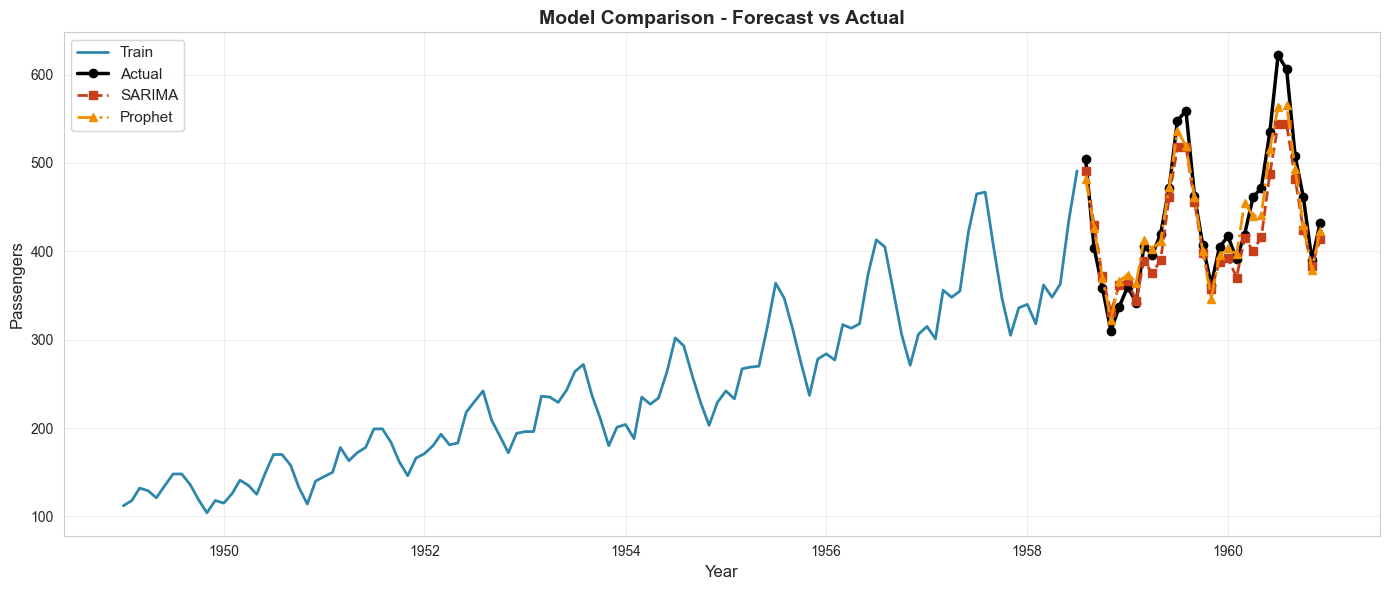

In [120]:
plt.figure(figsize=(14, 6))
plt.plot(train_data.index, train_data['Passengers'], label='Train', color='#2E86AB', linewidth=2)
plt.plot(test_data.index, test_data['Passengers'], label='Actual', color='black', linewidth=2.5, marker='o')
plt.plot(test_data.index, sarima_predictions, label='SARIMA', color='#C73E1D', linewidth=2, linestyle='--', marker='s')
plt.plot(test_data.index, prophet_predictions, label='Prophet', color='#F18F01', linewidth=2, linestyle='-.', marker='^')
plt.title('Model Comparison - Forecast vs Actual', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Passengers', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [121]:
# Display forecast values
forecast_df = pd.DataFrame({
    'Month': future_dates_range.strftime('%Y-%m'),
    'SARIMA': sarima_future.values,
    'Prophet': prophet_future
})

print("\n📅 12-Month Forecast:")
print(forecast_df.to_string(index=False))


📅 12-Month Forecast:
  Month     SARIMA    Prophet
1961-01 447.222620 449.728230
1961-02 422.734099 431.006236
1961-03 457.700895 491.481950
1961-04 492.277506 492.951258
1961-05 505.563366 502.174598
1961-06 565.671782 577.086066
1961-07 651.986405 651.431586
1961-08 639.634243 648.132504
1961-09 543.058846 551.395445
1961-10 493.727026 487.226620
1961-11 426.938001 422.963940
1961-12 470.135609 471.904393


### 9. SAVE MODELS FOR STREAMLIT

In [122]:
# Save the full dataset
df.to_csv('air_passengers_data.csv')

# Save SARIMA model
sarima_full_result.save('sarima_model.pkl')

# Save Prophet model
with open('prophet_model.pkl', 'wb') as f:
    pickle.dump(prophet_full, f)

# Save evaluation metrics
metrics = {
    'sarima': {'mae': sarima_mae, 'rmse': sarima_rmse, 'mape': sarima_mape, 'r2': sarima_r2},
    'prophet': {'mae': prophet_mae, 'rmse': prophet_rmse, 'mape': prophet_mape, 'r2': prophet_r2},
    'best_model': best_model
}

with open('model_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

# Save forecast data
forecast_df.to_csv('future_forecast.csv', index=False)

print("✅ Models and data saved successfully!")
print("\nFiles created:")
print("  - air_passengers_data.csv")
print("  - sarima_model.pkl")
print("  - prophet_model.pkl")
print("  - model_metrics.pkl")
print("  - future_forecast.csv")
print("  - business_insights.csv")
print("\n🎉 Ready for Streamlit deployment!")

✅ Models and data saved successfully!

Files created:
  - air_passengers_data.csv
  - sarima_model.pkl
  - prophet_model.pkl
  - model_metrics.pkl
  - future_forecast.csv
  - business_insights.csv

🎉 Ready for Streamlit deployment!


### 10. SUMMARY & INSIGHT

**Model Summary & Insights**

1. The Air Passengers dataset shows a strong upward trend and clear yearly seasonality,
   indicating that passenger demand increases over time with recurring seasonal patterns.
2. The SARIMA(1,1,1)(1,1,1,12) model captures both trend and seasonal components.
   However, its performance is slightly lower compared to Prophet.
3. Model Evaluation Results:
   - SARIMA  → RMSE: 31.79 | MAE: 25.27 | MAPE: 5.43% | R²: 0.834
   - Prophet → RMSE: 22.59 | MAE: 18.32 | MAPE: 4.06% | R²: 0.916
4. Prophet achieved better performance across all evaluation metrics,
   indicating it models the trend and seasonality more effectively for this dataset.
5. Based on the lowest RMSE and highest R² score, Prophet is selected as the best model.
6. Both models were retrained using the full dataset to generate a 12-month future forecast,
   which shows a continued upward trend with seasonal fluctuations.

---

**Business Insight**

Air passenger demand shows a strong upward trend with clear seasonal patterns.
The Prophet model provides the most accurate forecasts, making it suitable for
short-term passenger demand prediction.

The 12-month forecast suggests passenger numbers will continue to grow with
recurring seasonal peaks, which can help airlines plan capacity, flight schedules,
and resource allocation during high-demand periods.

---

**Conclusion:**
The forecasting results suggest that air passenger demand is expected to continue
growing in the coming months, following similar seasonal patterns observed in
historical data.

### Next Steps: Deploy to Streamlit

Run file `streamlit_app.py` using command:
```bash
streamlit run streamlit_app.py
```

Apllication will open with features:
- ✅ Interactive time series visualization
- ✅ Model comparison dashboard
- ✅ Future forecasting with adjustable periods
- ✅ Model evaluation metrics
- ✅ Download forecast results